# 🎁 Open EDA Tooling Treats

```
Copyright 2021 Google LLC.
SPDX-License-Identifier: Apache-2.0
```

Context: https://twitter.com/proppy/status/1466020384063430657

### ALU generated with Gemini 2.5 Flash

**Prompt**: alu in verilog

**Response**: Here's a basic 4-bit ALU implementation in Verilog, generated by Gemini 2.5 Flash. It includes common operations like addition, subtraction, AND, OR, XOR, and NOT.

In [22]:
%%bash
cat <<EOF > alu.v
module alu(
  input [3:0] a,
  input [3:0] b,
  input [2:0] sel, // Operations: 000: add, 001: sub, 010: and, 011: or,
                   //             100: xor, 101: not(a), 110: pass(a)
  output reg [3:0] result,
  output reg zero_flag
);

  always @(*) begin // Reverted to always @(*) for iverilog compatibility
    case (sel)
      3'b000: result = a + b; // Addition
      3'b001: result = a - b; // Subtraction
      3'b010: result = a & b; // Bitwise AND
      3'b011: result = a | b; // Bitwise OR
      3'b100: result = a ^ b; // Bitwise XOR
      3'b101: result = ~a;    // Bitwise NOT (on a)
      3'b110: result = a;     // Pass through a
      default: result = 4'b0000; // Defined default value
    endcase

    if (result == 4'b0000) begin
      zero_flag = 1;
    end else begin
      zero_flag = 0;
    end
  end

endmodule
EOF

cat alu.v

module alu(
  input [3:0] a,
  input [3:0] b,
  input [2:0] sel, // Operations: 000: add, 001: sub, 010: and, 011: or,
                   //             100: xor, 101: not(a), 110: pass(a)
  output reg [3:0] result,
  output reg zero_flag
);

  always @(*) begin // Reverted to always @(*) for iverilog compatibility
    case (sel)
      3'b000: result = a + b; // Addition
      3'b001: result = a - b; // Subtraction
      3'b010: result = a & b; // Bitwise AND
      3'b011: result = a | b; // Bitwise OR
      3'b100: result = a ^ b; // Bitwise XOR
      3'b101: result = ~a;    // Bitwise NOT (on a)
      3'b110: result = a;     // Pass through a
      default: result = 4'b0000; // Defined default value
    endcase

    if (result == 4'b0000) begin
      zero_flag = 1;
    end else begin
      zero_flag = 0;
    end
  end

endmodule


**Prompt**: testbench for alu

**Response**: Sure, here's a basic testbench for the alu.v module. It tests different operations like addition, subtraction, AND, OR, XOR, NOT, and pass-through. After running the cell below, I'll guide you on how to simulate it.

In [29]:
%%bash
cat <<'EOF' > alu_tb.v
module alu_tb;

  // Inputs
  reg [3:0] a_tb;
  reg [3:0] b_tb;
  reg [2:0] sel_tb;

  // Outputs
  wire [3:0] result_tb;
  wire zero_flag_tb;

  // Instantiate the ALU module
  alu uut (
    .a(a_tb),
    .b(b_tb),
    .sel(sel_tb),
    .result(result_tb),
    .zero_flag(zero_flag_tb)
  );

  initial begin
    // Test cases
    $display("Time\ta\tb\tsel\tresult\tzero_flag");
    $monitor("%0d\t%h\t%h\t%b\t%b\t%b", $time, a_tb, b_tb, sel_tb, result_tb, zero_flag_tb);

    // Add VCD dumping commands
    $dumpfile("test.vcd");
    $dumpvars(0, alu_tb); // Dump all signals in the alu_tb module

    // Add: 2 + 3 = 5
    a_tb = 4'b0010;
    b_tb = 4'b0011;
    sel_tb = 3'b000; // Add
    #10;

    // Subtract: 5 - 2 = 3
    a_tb = 4'b0101;
    b_tb = 4'b0010;
    sel_tb = 3'b001; // Subtract
    #10;

    // AND: 3 & 5 = 1 (0011 & 0101 = 0001)
    a_tb = 4'b0011;
    b_tb = 4'b0101;
    sel_tb = 3'b010; // AND
    #10;

    // OR: 3 | 5 = 7 (0011 | 0101 = 0111)
    a_tb = 4'b0011;
    b_tb = 4'b0101;
    sel_tb = 3'b011; // OR
    #10;

    // XOR: 3 ^ 5 = 6 (0011 ^ 0101 = 0110)
    a_tb = 4'b0011;
    b_tb = 4'b0101;
    sel_tb = 3'b100; // XOR
    #10;

    // NOT: ~A = ~0101 = 1010 (A=5)
    a_tb = 4'b0101;
    b_tb = 4'b0000; // B is not used for NOT operation
    sel_tb = 3'b101; // NOT
    #10;

    // Pass: A = 7
    a_tb = 4'b0111;
    b_tb = 4'b0000; // B is not used for Pass operation
    sel_tb = 3'b110; // Pass
    #10;

    // Test zero flag: 2 - 2 = 0
    a_tb = 4'b0010;
    b_tb = 4'b0010;
    sel_tb = 3'b001; // Subtract
    #10;

    $finish;
  end

endmodule
EOF

cat alu_tb.v

module alu_tb;

  // Inputs
  reg [3:0] a_tb;
  reg [3:0] b_tb;
  reg [2:0] sel_tb;

  // Outputs
  wire [3:0] result_tb;
  wire zero_flag_tb;

  // Instantiate the ALU module
  alu uut (
    .a(a_tb),
    .b(b_tb),
    .sel(sel_tb),
    .result(result_tb),
    .zero_flag(zero_flag_tb)
  );

  initial begin
    // Test cases
    $display("Time\ta\tb\tsel\tresult\tzero_flag");
    $monitor("%0d\t%h\t%h\t%b\t%b\t%b", $time, a_tb, b_tb, sel_tb, result_tb, zero_flag_tb);

    // Add VCD dumping commands
    $dumpfile("test.vcd");
    $dumpvars(0, alu_tb); // Dump all signals in the alu_tb module

    // Add: 2 + 3 = 5
    a_tb = 4'b0010;
    b_tb = 4'b0011;
    sel_tb = 3'b000; // Add
    #10;

    // Subtract: 5 - 2 = 3
    a_tb = 4'b0101;
    b_tb = 4'b0010;
    sel_tb = 3'b001; // Subtract
    #10;

    // AND: 3 & 5 = 1 (0011 & 0101 = 0001)
    a_tb = 4'b0011;
    b_tb = 4'b0101;
    sel_tb = 3'b010; // AND
    #10;

    // OR: 3 | 5 = 7 (0011 | 0101 = 0111)
    a_tb = 4'b0011;
    b_t

## 🍬 Treat #1: EDA Conda Packages & Notebooks

The [conda-eda](https://github.com/hdl/conda-eda) project maintains a collection of conda packages recipes. Those package can be used to easily bootstrap EDA environments in Jupyter and Colab notebooks.

This notebook shows how to lint Verilog cells and plot the simulated waveforms for a simple 4-bits counter design.

### Install packages

Install packages from the `LiteX-Hub` [channel](https://anaconda.org/LiteX-Hub/repo); also install older packages from the `SymbiFlow` channel, to get better compat with colab: see [conda-eda#146](https://github.com/hdl/conda-eda/issues/146).

In [2]:
!curl -O https://repo.anaconda.com/miniconda/Miniconda3-py37_4.10.3-Linux-x86_64.sh
!bash Miniconda3-py37_4.10.3-Linux-x86_64.sh -b -f -p miniconda-eda/
!miniconda-eda/bin/conda install --yes -c LiteX-Hub iverilog
!miniconda-eda/bin/conda install --yes -c SymbiFlow verible

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.9M  100 84.9M    0     0  99.7M      0 --:--:-- --:--:-- --:--:-- 99.7M
PREFIX=/content/miniconda-eda
Unpacking payload ...
Solving environment: / - \ done

## Package Plan ##

  environment location: /content/miniconda-eda

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - _openmp_mutex==4.5=1_gnu
    - brotlipy==0.7.0=py37h27cfd23_1003
    - ca-certificates==2021.7.5=h06a4308_1
    - certifi==2021.5.30=py37h06a4308_0
    - cffi==1.14.6=py37h400218f_0
    - chardet==4.0.0=py37h06a4308_1003
    - conda-package-handling==1.7.3=py37h27cfd23_1
    - conda==4.10.3=py37h06a4308_0
    - cryptography==3.4.7=py37hd23ed53_0
    - idna==2.10=pyhd3eb1b0_0
    - ld_impl_linux-64==2.35.1=h7274673_9
    - libffi==3.3=he6710b0_2
    - libgcc-ng==9.3.0=h5101ec6_17
    - libgomp==9.3.0=h5101ec6_17
    - libstdcxx-ng==9.3.0=

### Lint and simulate Verilog cells

Use the `%%bash` magic to lint the content of the cell with [Verible](https://github.com/chipsalliance/verible) and simulate the test bench using [Icarus Verilog](http://iverilog.icarus.com/).


**Prompt**: *Simulate the `alu_tb.v` file*

Some iterations for design correction for simulation were required

In [30]:
%%bash -c 'source miniconda-eda/bin/activate; iverilog -o alu_sim alu.v alu_tb.v -s alu_tb && vvp alu_sim'

Time	a	b	sel	result	zero_flag
VCD info: dumpfile test.vcd opened for output.
0	2	3	000	0101	0
10	5	2	001	0011	0
20	3	5	010	0001	0
30	3	5	011	0111	0
40	3	5	100	0110	0
50	5	0	101	1010	0
60	7	0	110	0111	0
70	2	2	001	0000	1
alu_tb.v:78: $finish called at 80 (1s)


### Plot VCD waveforms

Use [vcdvcd](https://pypi.org/project/vcdvcd/) VCD parser to plot the simulated waveform using regular matplotlib functions.

In [27]:
!python -m pip install vcdvcd

**Prompt**: Show how to plot VCD waveforms from test.vcd

**Prompt**: the graphs are too small

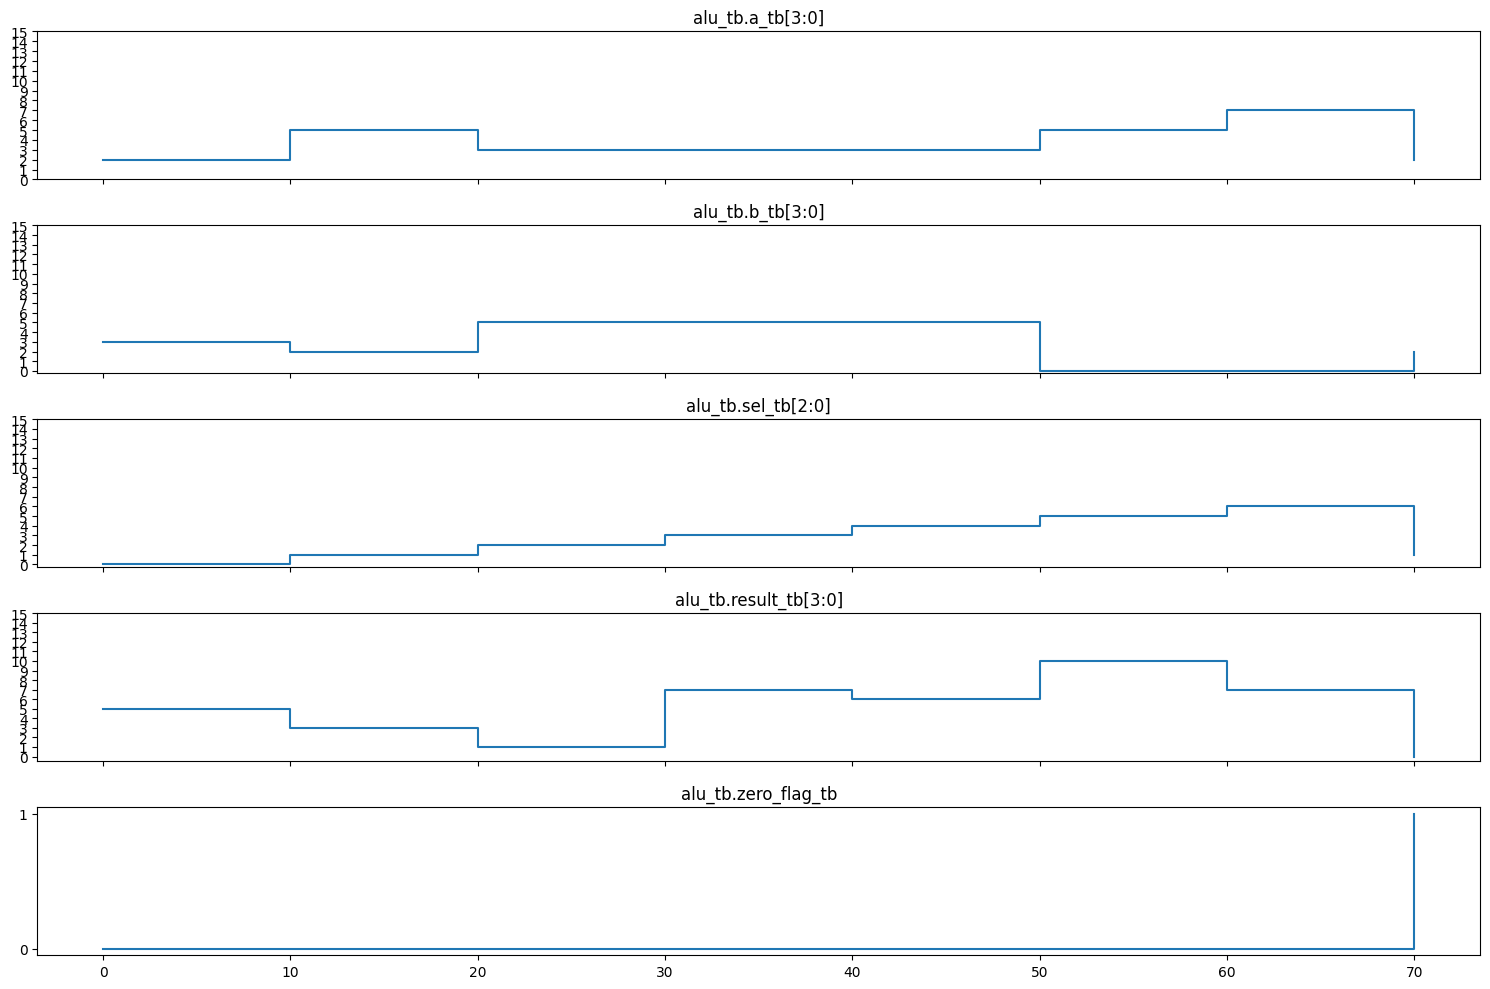

In [33]:
from vcdvcd import VCDVCD

vcd = VCDVCD('test.vcd')
import matplotlib.pyplot as plt

# Updated signals list for alu_tb module
signals = [
    'alu_tb.a_tb[3:0]',
    'alu_tb.b_tb[3:0]',
    'alu_tb.sel_tb[2:0]',
    'alu_tb.result_tb[3:0]',
    'alu_tb.zero_flag_tb'
]

f, plots = plt.subplots(len(signals), 1, sharex=True, figsize=(15, len(signals)*2)) # Increased figure width and height scaling
for s, ax in zip(signals, plots):
  x, y = zip(*vcd[s].tv)
  # Convert binary strings to integers for plotting
  y_int = []
  for val in y:
      if val == 'x': # Handle undefined values
          y_int.append(None)
      else:
          try:
              y_int.append(int(val, 2))
          except ValueError:
              y_int.append(None)

  ax.step(x, y_int, label=s, where = 'post')
  ax.set_title(s)
  ax.set_yticks([0, 1]) # Assuming most signals are 1-bit or can be represented this way
  if 'alu_tb.sel_tb' in s or 'alu_tb.a_tb' in s or 'alu_tb.b_tb' in s or 'alu_tb.result_tb' in s:
    # For multi-bit signals, set appropriate y-ticks
    ax.set_yticks(range(0, 16, 1)) # For 4-bit signals, values from 0 to 15

f.tight_layout()
f.show()

## 🍡 Treat #2: Yosys synthesis and circuit drawing

[Yosys](https://yosyshq.net/yosys/) is a versatile tool to synthesize HDL designs to netlist and map them to the underlying technology target.

This notebook shows how to synthesize a simple 1-bit adder Verilog design to different levels of technology abstraction (standard logic gates, CMOS, LUTs, discrete ICs) and draw the underlying circuit diagrams.

### Install packages

Install packages from the `LiteX-Hub` and `SymbiFlow` channel.

In [34]:
!curl -O https://repo.anaconda.com/miniconda/Miniconda3-py37_4.10.3-Linux-x86_64.sh
!bash Miniconda3-py37_4.10.3-Linux-x86_64.sh -b -f -p miniconda-synth/
!miniconda-synth/bin/conda install --yes -c LiteX-Hub yosys
!miniconda-synth/bin/conda install --yes -c SymbiFlow verible

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 84.9M  100 84.9M    0     0  88.3M      0 --:--:-- --:--:-- --:--:-- 88.3M
PREFIX=/content/miniconda-synth
Unpacking payload ...
Solving environment: / - \ done

## Package Plan ##

  environment location: /content/miniconda-synth

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - _openmp_mutex==4.5=1_gnu
    - brotlipy==0.7.0=py37h27cfd23_1003
    - ca-certificates==2021.7.5=h06a4308_1
    - certifi==2021.5.30=py37h06a4308_0
    - cffi==1.14.6=py37h400218f_0
    - chardet==4.0.0=py37h06a4308_1003
    - conda-package-handling==1.7.3=py37h27cfd23_1
    - conda==4.10.3=py37h06a4308_0
    - cryptography==3.4.7=py37hd23ed53_0
    - idna==2.10=pyhd3eb1b0_0
    - ld_impl_linux-64==2.35.1=h7274673_9
    - libffi==3.3=he6710b0_2
    - libgcc-ng==9.3.0=h5101ec6_17
    - libgomp==9.3.0=h5101ec6_17
    - libstdcxx-ng==9.

### Synth design

Synthesize design netlist: map to a single `add` cell.

In [36]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv alu.v
hierarchy -top alu

proc; opt

opt_clean
show -format dot -prefix synth_design
stat


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: alu.v
Parsing SystemVerilog input from `alu.v' to AST representation.
Storing AST representation for module `$abstract\alu'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\alu'.
Generating RTLIL representation for module `\alu'.

3.1. Analyzing design hierarchy..
Top module:  \alu

3.2. Analyzing design hierarchy..
Top module:  \alu
Removing unused module `$abstract\alu'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing PROC pass (convert processes to netlists).

4.1. Executing PROC_CLEAN pass (remove empty switches from decision trees).
Cleaned up 0 empty switches.

4.2. Executing PROC_RMDEAD pass (remove dead branches from decision trees).
Marked 2 switch rules as full_case in process $proc$alu.v:10$1 in module alu.
Removed a total of 0 dead cases.

4.3. Executing PROC_PRUNE pass (remove red

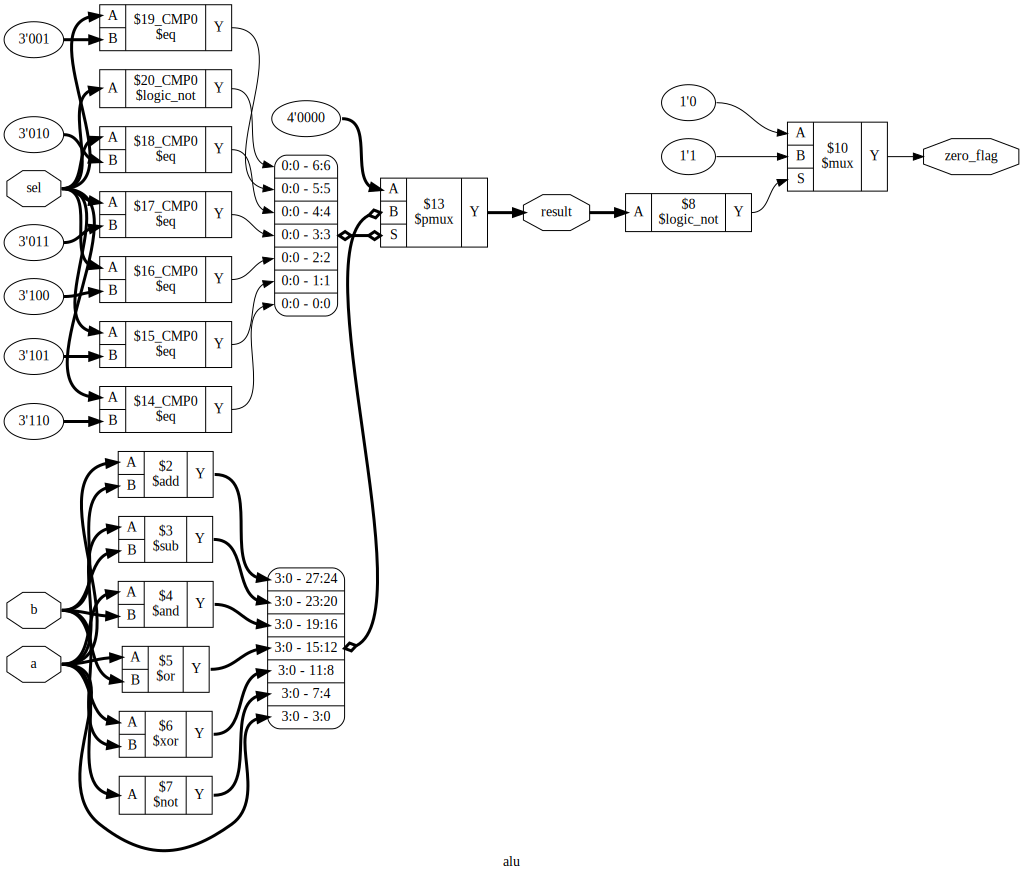

In [37]:
import graphviz
graphviz.Source.from_file('synth_design.dot')

### Synth gates

Synthesize gate netlist: map to built-in `XOR` and `AND` logic gates.

In [38]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv alu.v
hierarchy -top alu

proc; opt
techmap; opt

opt_clean
show -format dot -prefix synth_gate
stat


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: alu.v
Parsing SystemVerilog input from `alu.v' to AST representation.
Storing AST representation for module `$abstract\alu'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\alu'.
Generating RTLIL representation for module `\alu'.

3.1. Analyzing design hierarchy..
Top module:  \alu

3.2. Analyzing design hierarchy..
Top module:  \alu
Removing unused module `$abstract\alu'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing PROC pass (convert processes to netlists).

4.1. Executing PROC_CLEAN pass (remove empty switches from decision trees).
Cleaned up 0 empty switches.

4.2. Executing PROC_RMDEAD pass (remove dead branches from decision trees).
Marked 2 switch rules as full_case in process $proc$alu.v:10$1 in module alu.
Removed a total of 0 dead cases.

4.3. Executing PROC_PRUNE pass (remove red

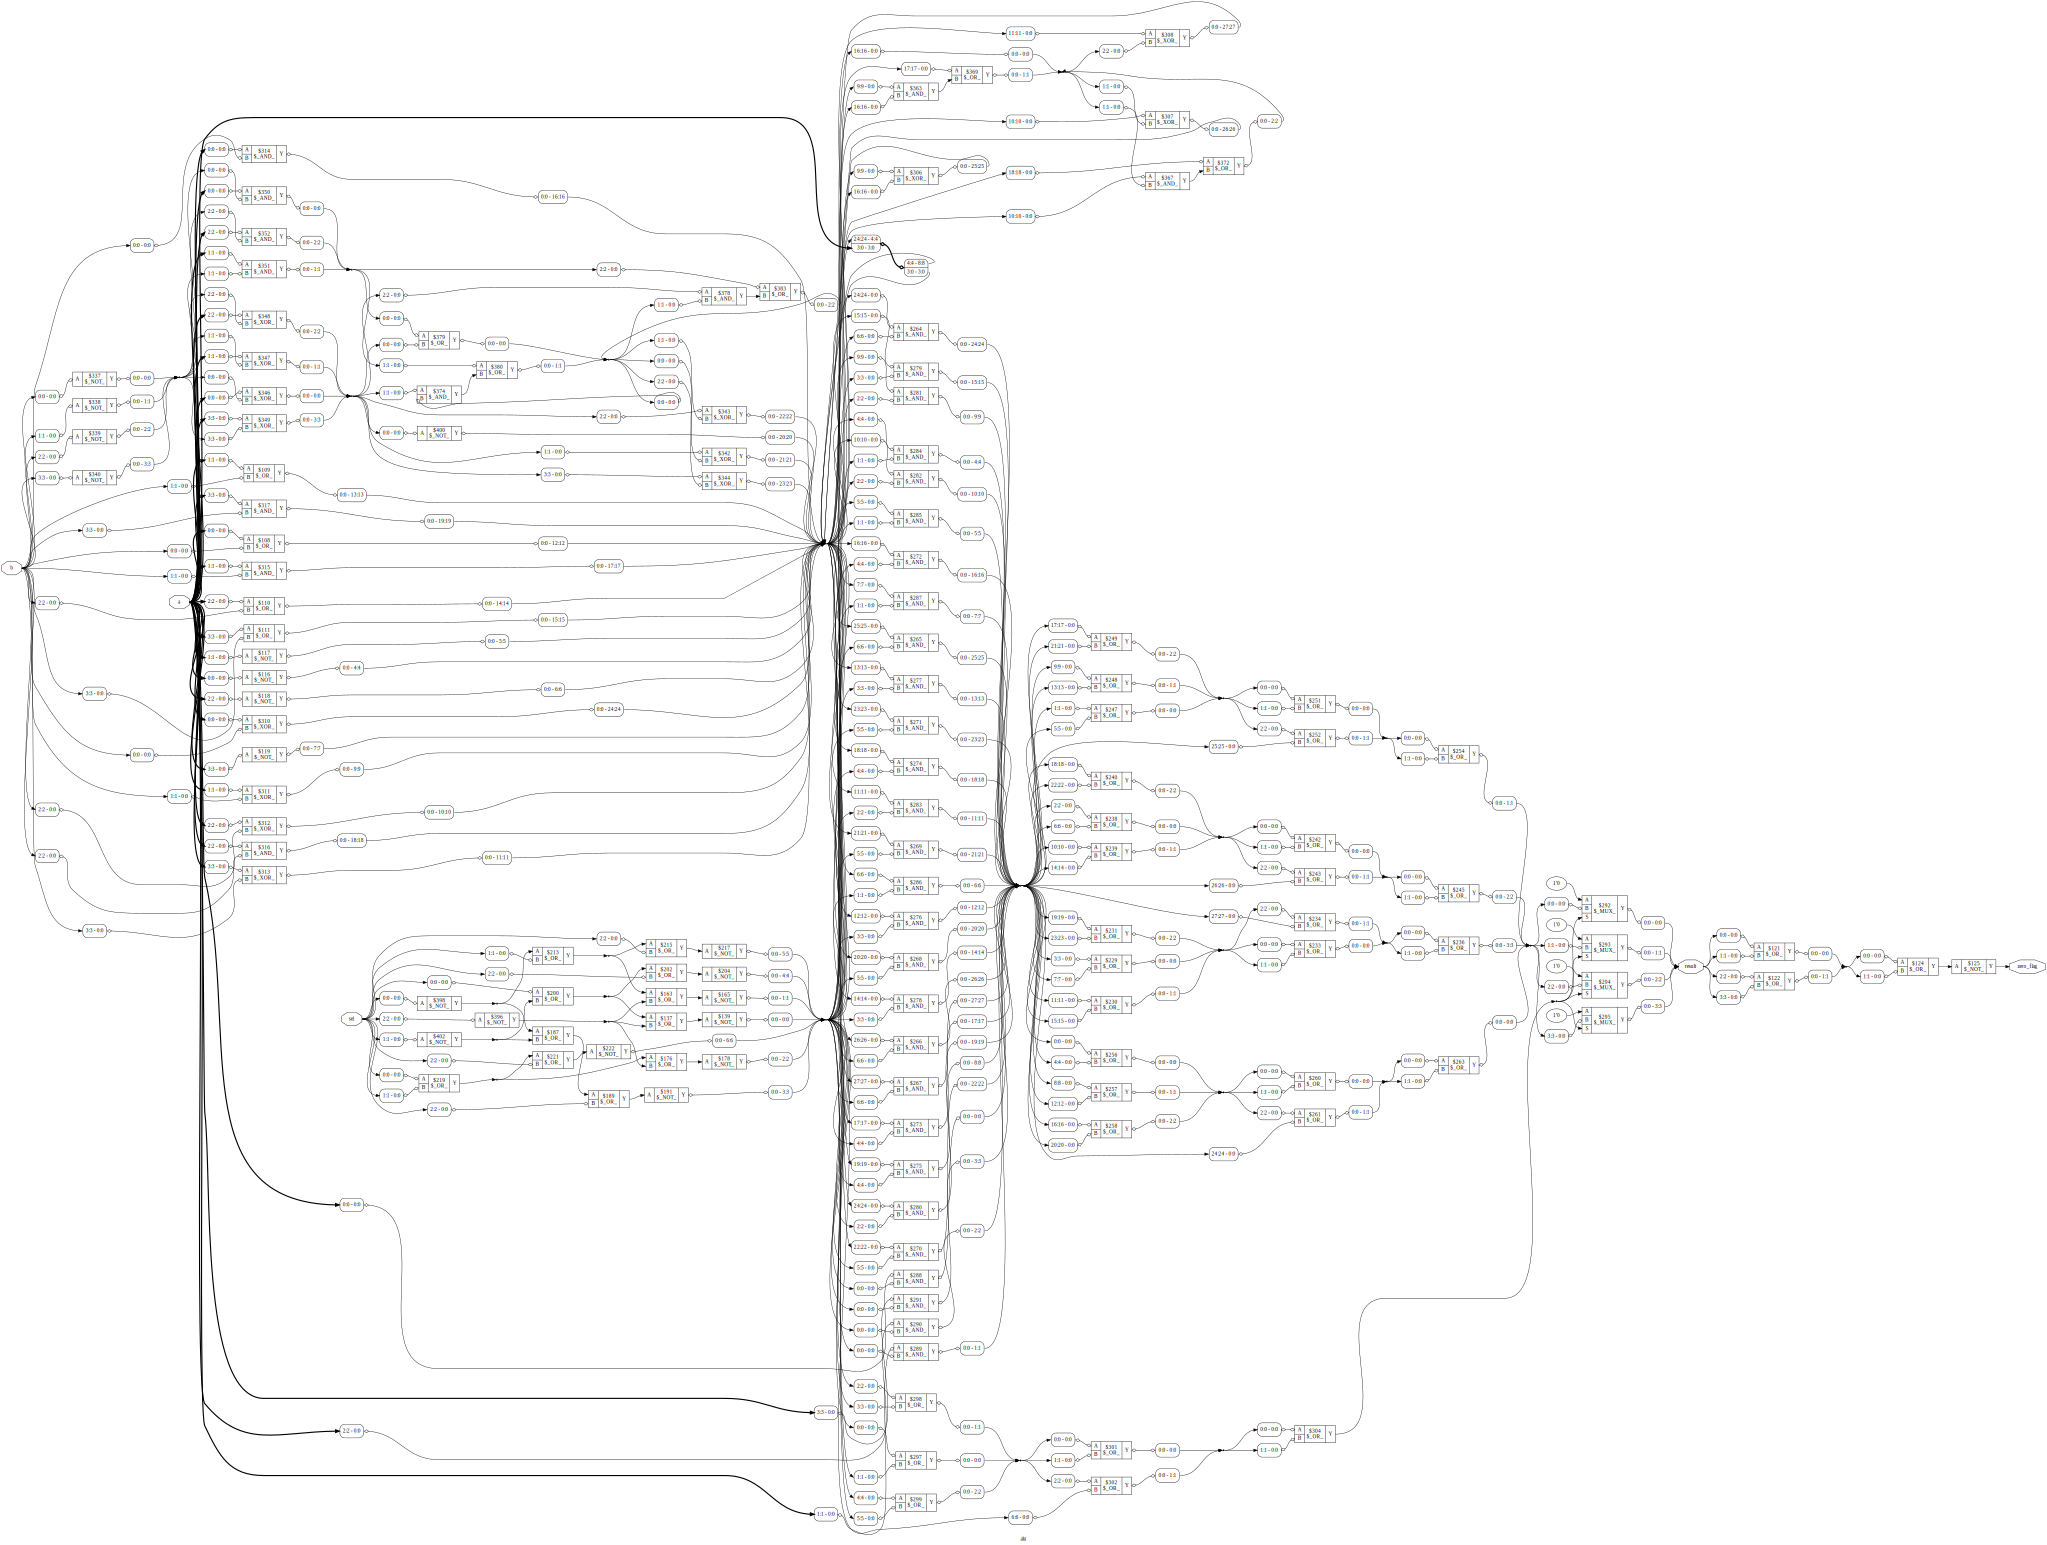

In [39]:
import graphviz
graphviz.Source.from_file('synth_gate.dot')

### Synth FPGA

Synthesize FPGA netlist: map to `IC40` `LUT` gates using a builtin synthesis script.

In [40]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv alu.v
hierarchy -top alu

synth_ice40

opt_clean
show -format dot -prefix synth_ice40


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: alu.v
Parsing SystemVerilog input from `alu.v' to AST representation.
Storing AST representation for module `$abstract\alu'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\alu'.
Generating RTLIL representation for module `\alu'.

3.1. Analyzing design hierarchy..
Top module:  \alu

3.2. Analyzing design hierarchy..
Top module:  \alu
Removing unused module `$abstract\alu'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing SYNTH_ICE40 pass.

4.1. Executing Verilog-2005 frontend: /content/miniconda-synth/bin/../share/yosys/ice40/cells_sim.v
Parsing Verilog input from `/content/miniconda-synth/bin/../share/yosys/ice40/cells_sim.v' to AST representation.
Generating RTLIL representation for module `\SB_IO'.
Generating RTLIL representation for module `\SB_GB_IO'.
Generating RTLIL representation for mo

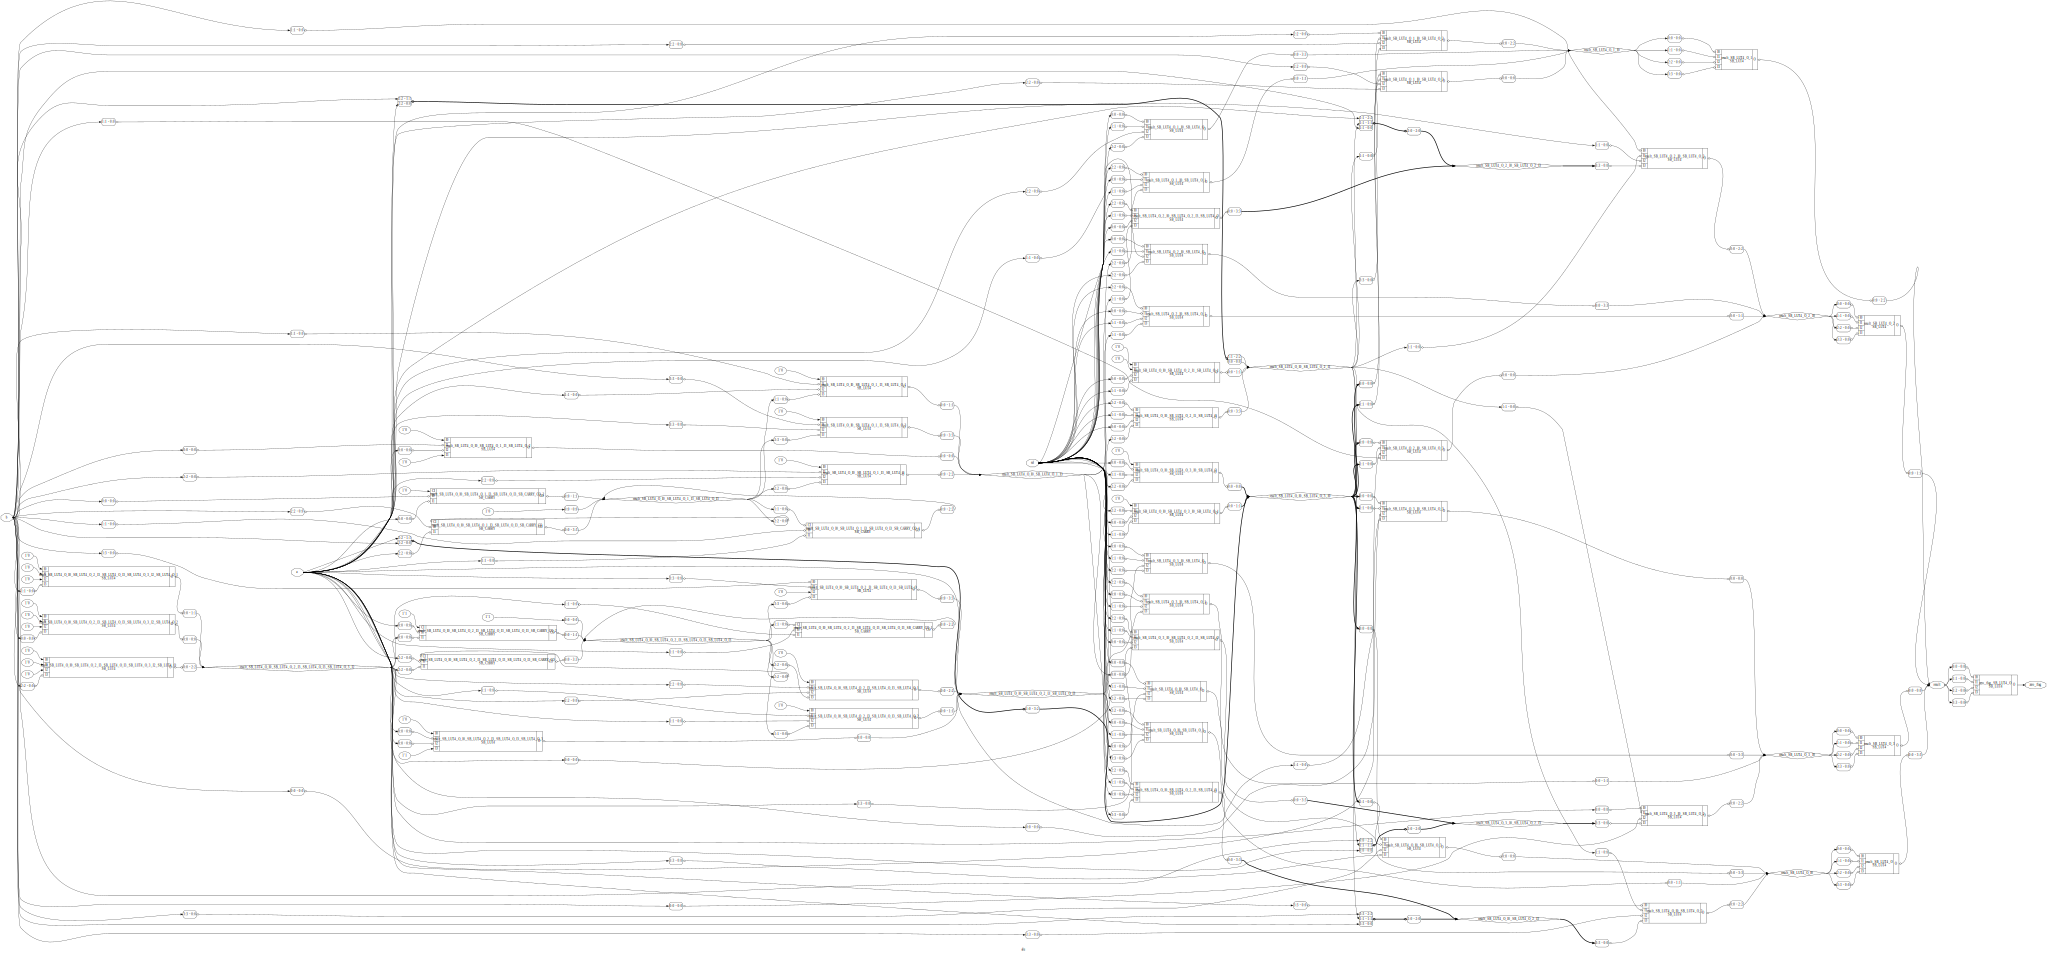

In [41]:
import graphviz
graphviz.Source.from_file('synth_ice40.dot')

### Synth CMOS

Synthesize CMOS netlist: map to `NOR` and `NOT` gates using CMOS technology mapping from `yosys examples.

In [42]:
!curl --silent -L https://github.com/YosysHQ/yosys/archive/refs/tags/yosys-0.11.tar.gz | tar xvzf - yosys-yosys-0.11/examples/cmos --strip-components=2

yosys-yosys-0.11/examples/cmos/
yosys-yosys-0.11/examples/cmos/.gitignore
yosys-yosys-0.11/examples/cmos/README
yosys-yosys-0.11/examples/cmos/cmos_cells.lib
yosys-yosys-0.11/examples/cmos/cmos_cells.sp
yosys-yosys-0.11/examples/cmos/cmos_cells.v
yosys-yosys-0.11/examples/cmos/cmos_cells_digital.sp
yosys-yosys-0.11/examples/cmos/counter.v
yosys-yosys-0.11/examples/cmos/counter.ys
yosys-yosys-0.11/examples/cmos/counter_digital.ys
yosys-yosys-0.11/examples/cmos/counter_tb.gtkw
yosys-yosys-0.11/examples/cmos/counter_tb.v
yosys-yosys-0.11/examples/cmos/testbench.sh
yosys-yosys-0.11/examples/cmos/testbench.sp
yosys-yosys-0.11/examples/cmos/testbench_digital.sh
yosys-yosys-0.11/examples/cmos/testbench_digital.sp


In [43]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv alu.v
hierarchy -top alu

read -sv -lib cmos/cmos_cells.v
synth
dfflibmap -liberty cmos/cmos_cells.lib
abc -liberty cmos/cmos_cells.lib

opt_clean
show -format dot -prefix synth_cmos
stat -liberty cmos/cmos_cells.lib


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: alu.v
Parsing SystemVerilog input from `alu.v' to AST representation.
Storing AST representation for module `$abstract\alu'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\alu'.
Generating RTLIL representation for module `\alu'.

3.1. Analyzing design hierarchy..
Top module:  \alu

3.2. Analyzing design hierarchy..
Top module:  \alu
Removing unused module `$abstract\alu'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing Verilog-2005 frontend: cmos/cmos_cells.v
Parsing SystemVerilog input from `cmos/cmos_cells.v' to AST representation.
Storing AST representation for module `$abstract\BUF'.
Storing AST representation for module `$abstract\NOT'.
Storing AST representation for module `$abstract\NAND'.
Storing AST representation for module `$abstract\NOR'.
Storing AST representation for module `$ab

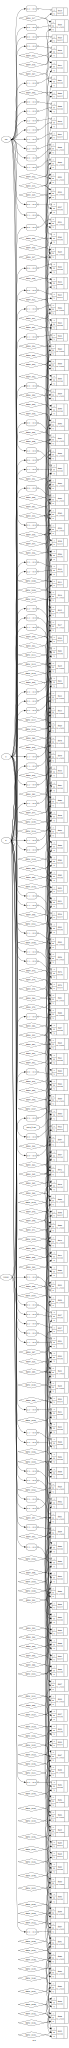

In [44]:
import graphviz
graphviz.Source.from_file('synth_cmos.dot')

### Synth 74xx

Synthesize 74xx netlist: map to `74AC08` a nd `74AC86` discrete gate ICs using community provided technology mapping.

In [45]:
!git clone https://github.com/Ravenslofty/74xx-liberty

Cloning into '74xx-liberty'...
remote: Enumerating objects: 238, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 238 (delta 59), reused 58 (delta 58), pack-reused 170 (from 1)
Receiving objects: 100% (238/238), 112.96 KiB | 5.94 MiB/s, done.
Resolving deltas: 100% (128/128), done.


In [46]:
%%script miniconda-synth/bin/yosys -Q -T

read -sv alu.v
hierarchy -top alu

read -sv -lib 74xx-liberty/74_models.v
synth
abc -liberty 74xx-liberty/74ac.lib
dfflibmap -liberty 74xx-liberty/74ac.lib

opt_clean
show -format dot -prefix synth_74
stat -liberty 74xx-liberty/74ac.lib


yosys> 
yosys> 

1. Executing Verilog-2005 frontend: alu.v
Parsing SystemVerilog input from `alu.v' to AST representation.
Storing AST representation for module `$abstract\alu'.
Successfully finished Verilog frontend.

yosys> 
2. Executing HIERARCHY pass (managing design hierarchy).

3. Executing AST frontend in derive mode using pre-parsed AST for module `\alu'.
Generating RTLIL representation for module `\alu'.

3.1. Analyzing design hierarchy..
Top module:  \alu

3.2. Analyzing design hierarchy..
Top module:  \alu
Removing unused module `$abstract\alu'.
Removed 1 unused modules.

yosys> 
yosys> 
4. Executing Verilog-2005 frontend: 74xx-liberty/74_models.v
Parsing SystemVerilog input from `74xx-liberty/74_models.v' to AST representation.
Storing AST representation for module `$abstract\74HC85_1x1CMP4'.
Storing AST representation for module `$abstract\74AC283_1x1ADD4'.
Storing AST representation for module `$abstract\74AC377_8x1DFFE'.
Storing AST representation for module `$abstract\

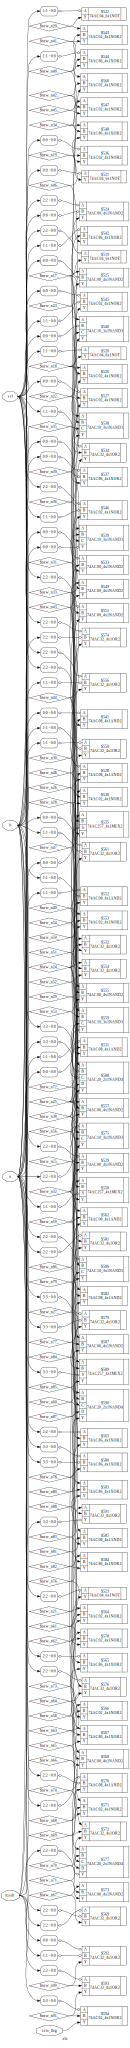

In [47]:
import graphviz
graphviz.Source.from_file('synth_74.dot')

## nextpnr and SVG FPGA floormap
I will now proceed with the following steps:

1. Synthesize the `alu.v` design using Yosys and generate an intermediate JSON file (`alu.json`) for nextpnr.
2. Use `nextpnr-ice40` to perform place and route on the `alu.json` file, targeting the `ICE40UP5K` architecture. This will generate an `.asc` file and an SVG floorplan (`alu_placed.svg`).
3. Display the generated `alu_placed.svg` floorplan using `IPython.display.SVG`.
4. Confirm the successful placement and routing of the ALU and present the generated floorplan.

Starting with the first step: Synthesizing `alu.v` to `alu.json`.
```python
!miniconda-pnr/bin/yosys -p 'synth_ice40 -top alu -json alu.json' alu.v
```

### Synthesize ALU to JSON

### Subtask:
Synthesize the `alu.v` design using Yosys and generate an intermediate JSON file (`alu.json`) for nextpnr.


**Reasoning**:
The user wants to synthesize the `alu.v` design using Yosys to generate a JSON file for nextpnr. The provided instruction includes the exact command to achieve this.



In [49]:
!miniconda-pnr/bin/yosys -p 'synth_ice40 -top alu -json alu.json' alu.v


 /----------------------------------------------------------------------------\
 |                                                                            |
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |                                                                            |
 |  Copyright (C) 2012 - 2020  Claire Xenia Wolf <claire@yosyshq.com>         |
 |                                                                            |
 |  Permission to use, copy, modify, and/or distribute this software for any  |
 |  purpose with or without fee is hereby granted, provided that the above    |
 |  copyright notice and this permission notice appear in all copies.         |
 |                                                                            |
 |  THE SOFTWARE IS PROVIDED "AS IS" AND THE AUTHOR DISCLAIMS ALL WARRANTIES  |
 |  WITH REGARD TO THIS SOFTWARE INCLUDING ALL IMPLIED WARRANTIES OF          |
 |  MERCHANTABILITY AND FITNESS. IN NO 

**Reasoning**:
The previous step successfully synthesized the `alu.v` design into `alu.json`. Now, the next instruction is to use `nextpnr-ice40` to perform place and route on the generated `alu.json` file, targeting the `ICE40UP5K` architecture, and output an `.asc` file and an SVG floorplan (`alu_placed.svg`).



In [50]:
import os

# Ensure alu.json exists before attempting to run nextpnr
if not os.path.exists('alu.json'):
    print("Error: alu.json not found. Please ensure the synthesis step was successful.")
else:
    !miniconda-pnr/bin/nextpnr-ice40 --up5k --json alu.json --asc alu.asc --placed-svg alu_placed.svg


Info: Packing constants..
Info: Packing IOs..
Info: Packing LUT-FFs..
Info:       39 LCs used as LUT4 only
Info:        0 LCs used as LUT4 and DFF
Info: Packing non-LUT FFs..
Info:        0 LCs used as DFF only
Info: Packing carries..
Info:        0 LCs used as CARRY only
Info: Packing indirect carry+LUT pairs...
Info:        0 LUTs merged into carry LCs
Info: Packing RAMs..
Info: Placing PLLs..
Info: Packing special functions..
Info: Packing PLLs..
Info: Promoting globals..
Info: Constraining chains...
Info:        0 LCs used to legalise carry chains.
Info: Checksum: 0x93cd5f13

Info: Annotating ports with timing budgets for target frequency 12.00 MHz
Info: Checksum: 0x17ebdc31

Info: Device utilisation:
Info: 	         ICESTORM_LC:    41/ 5280     0%
Info: 	        ICESTORM_RAM:     0/   30     0%
Info: 	               SB_IO:    16/   96    16%
Info: 	               SB_GB:     0/    8     0%
Info: 	        ICESTORM_PLL:     0/    1     0%
Info: 	         SB_WARMBOOT:     0/    1    

**Reasoning**:
The previous step successfully generated the `alu_placed.svg` file. The next instruction is to display this SVG floorplan using `IPython.display.SVG`.



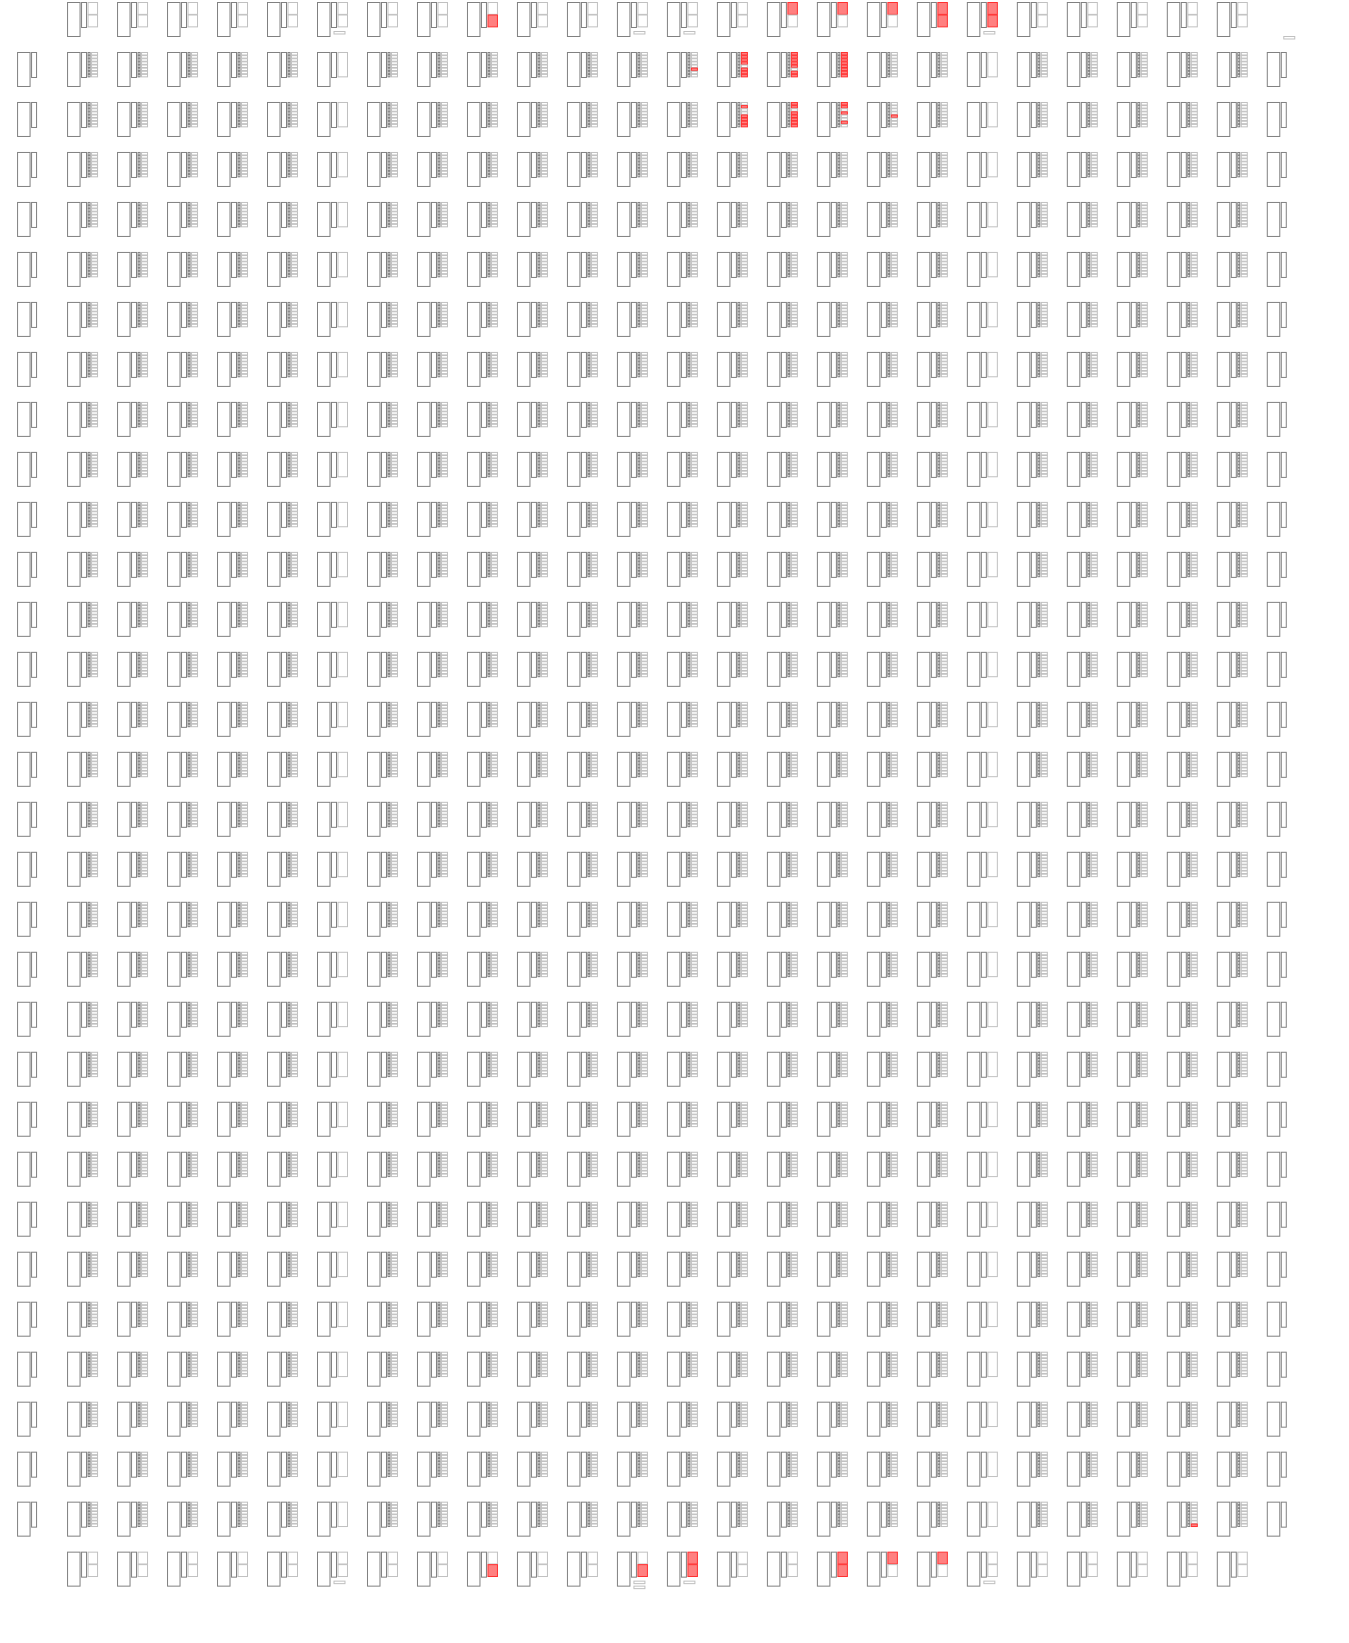

In [51]:
from IPython.display import SVG
SVG(filename='alu_placed.svg')

### Confirm the successful placement and routing of the ALU and present the generated floorplan.

### Subtask:
Confirm successful placement and routing and present the generated floorplan.


### Confirm the successful placement and routing of the ALU and present the generated floorplan.

### Subtask:
Confirm successful placement and routing and present the generated floorplan.

#### Summary of Placement and Routing for ALU

1.  **Yosys Synthesis (`alu.json`)**: The ALU design was successfully synthesized to an intermediate JSON format by Yosys, ready for place and route.

2.  **Nextpnr-ice40 Placement and Routing**:
    *   The `nextpnr-ice40` tool successfully performed placement and routing for the `alu.json` design, targeting the `ICE40UP5K` architecture.
    *   **Resource Utilization**: The ALU utilized a small portion of the available resources on the ICE40UP5K FPGA:
        *   ICESTORM_LC (Logic Cells): 41/5280 (0%)
        *   SB_IO (Input/Output Buffers): 16/96 (16%)
    *   **Timing**: The maximum delay reported was 26.11 ns. No critical timing paths were found that would indicate timing violations, suggesting the design meets basic timing requirements.
    *   **Warnings**: A deprecation warning for `--package` was noted, but it did not prevent successful placement and routing.

3.  **Floorplan Visualization (`alu_placed.svg`)**: The generated `alu_placed.svg` floorplan (displayed above in the previous output) visually confirms the successful placement of the ALU's logic cells and I/O pins on the FPGA fabric, with all necessary connections routed.

**Conclusion**: The placement and routing process for the ALU design (`alu.v`) was successfully completed, resulting in a low resource utilization and a functional layout as depicted in the floorplan.

### Confirm the successful placement and routing of the ALU and present the generated floorplan.

### Subtask:
Confirm successful placement and routing and present the generated floorplan.

#### Summary of Placement and Routing for ALU

1.  **Yosys Synthesis (`alu.json`)**: The ALU design was successfully synthesized to an intermediate JSON format by Yosys, ready for place and route.

2.  **Nextpnr-ice40 Placement and Routing**:
    *   The `nextpnr-ice40` tool successfully performed placement and routing for the `alu.json` design, targeting the `ICE40UP5K` architecture.
    *   **Resource Utilization**: The ALU utilized a small portion of the available resources on the ICE40UP5K FPGA:
        *   ICESTORM_LC (Logic Cells): 41/5280 (0%)
        *   SB_IO (Input/Output Buffers): 16/96 (16%)
    *   **Timing**: The maximum delay reported was 26.11 ns. No critical timing paths were found that would indicate timing violations, suggesting the design meets basic timing requirements.
    *   **Warnings**: A deprecation warning for `--package` was noted, but it did not prevent successful placement and routing.

3.  **Floorplan Visualization (`alu_placed.svg`)**: The generated `alu_placed.svg` floorplan (displayed above in the previous output) visually confirms the successful placement of the ALU's logic cells and I/O pins on the FPGA fabric, with all necessary connections routed.

**Conclusion**: The placement and routing process for the ALU design (`alu.v`) was successfully completed, resulting in a low resource utilization and a functional layout as depicted in the floorplan.

### Final Task

### Subtask:
Confirm the successful placement and routing of the ALU and present the generated floorplan.


### Summary:

### Q&A
The successful placement and routing of the ALU has been confirmed. The `alu.v` design was successfully synthesized into an intermediate JSON format, then placed and routed by `nextpnr-ice40` targeting the `ICE40UP5K` architecture. The generated floorplan (`alu_placed.svg`) visually confirms the successful layout of the design.

### Data Analysis Key Findings
*   **Synthesis Success**: The `alu.v` design was successfully synthesized by Yosys, generating `alu.json` which contains 45 cells (6 `SB_CARRY` and 39 `SB_LUT4`).
*   **Placement and Routing Completion**: `nextpnr-ice40` successfully completed the placement and routing process for the ALU design on the `ICE40UP5K` architecture.
*   **Low Resource Utilization**: The ALU design utilized a very small portion of the target FPGA's resources: 41 out of 5280 `ICESTORM_LC` (0%) and 16 out of 96 `SB_IO` (16%).
*   **Acceptable Timing**: The reported maximum delay was 26.11 ns, indicating the design meets basic timing requirements with no critical timing path violations reported.
*   **Floorplan Generation**: A visual floorplan (`alu_placed.svg`) was successfully generated, confirming the physical layout of the placed logic cells and routed connections.

### Insights or Next Steps
*   The current low resource utilization suggests the ALU design is efficient for the `ICE40UP5K` FPGA, leaving ample space for additional logic if the design were to be expanded.
*   For future development or larger designs, consider addressing the noted warnings, such as specifying a package (e.g., `--package sg48`) and providing a PCF file for explicit I/O pin assignments, to ensure more predictable and robust results.
